# Tugas Minggu 11 – Analisis dan Visualisasi Jaringan Kolaborasi / Interaksi
## Analisis Centrality & Visualisasi pada Jaringan Kolaborasi Penulis Ilmiah
### Group 1
- William Azaria Simanjuntak (103012340356)
- Muhammad Jovan Pratama (1301224156)
- Azkal Azkiya Zalfa (1301224422)
- Meyra Firdhaus Isnaini (103012300179)
- Elshaday Debora Sambeka (103012330290)

## Deskripsi Dataset

**Dataset:** `ca-sandi_auths.mtx` — Jaringan kolaborasi penulis dari University of California San Diego (UCSD)

**Sumber:** Koblenz Network Collection (KONECT) — http://konect.cc/networks/ca-sandi_auths/

Dataset ini merepresentasikan jaringan kolaborasi antar penulis ilmiah di lingkungan UCSD. Setiap **node** mewakili seorang penulis, dan setiap **edge** merepresentasikan adanya makalah ilmiah yang ditulis bersama (ko-authorship). Bobot edge menunjukkan berapa kali dua penulis berkolaborasi bersama.

- **Jumlah node:** 86 penulis
- **Jumlah edge:** 124 kolaborasi
- **Tipe graf:** Undirected (tidak berarah) — Weighted (berbobot)

## Import Library

In [44]:

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


## Load Dataset

In [45]:
df = pd.read_csv('ca-sandi_auths.mtx', comment='%', sep=r'\s+',header=None, names=['source', 'target', 'weight'])
df = df.iloc[1:].reset_index(drop=True)
df.head(5)

,source,target,weight
0,37,1,2
1,18,2,1
2,26,2,2
3,32,2,1
4,33,2,1


## Preprocessing Data

In [46]:
# Ubah tipe data
df = df.astype(int)

# Hapus duplikasi data
df = df.drop_duplicates()

# Hapus self-loop
df = df[df['source'] != df['target']]

# Reset index
df = df.reset_index(drop=True)

## Graf

In [47]:

G = nx.from_pandas_edgelist(
    df,
    source='source',
    target='target',
    edge_attr='weight',
    create_using=nx.Graph()
)

print("Jumlah node:", G.number_of_nodes())
print("Jumlah edge:", G.number_of_edges())


Jumlah node: 86
Jumlah edge: 123


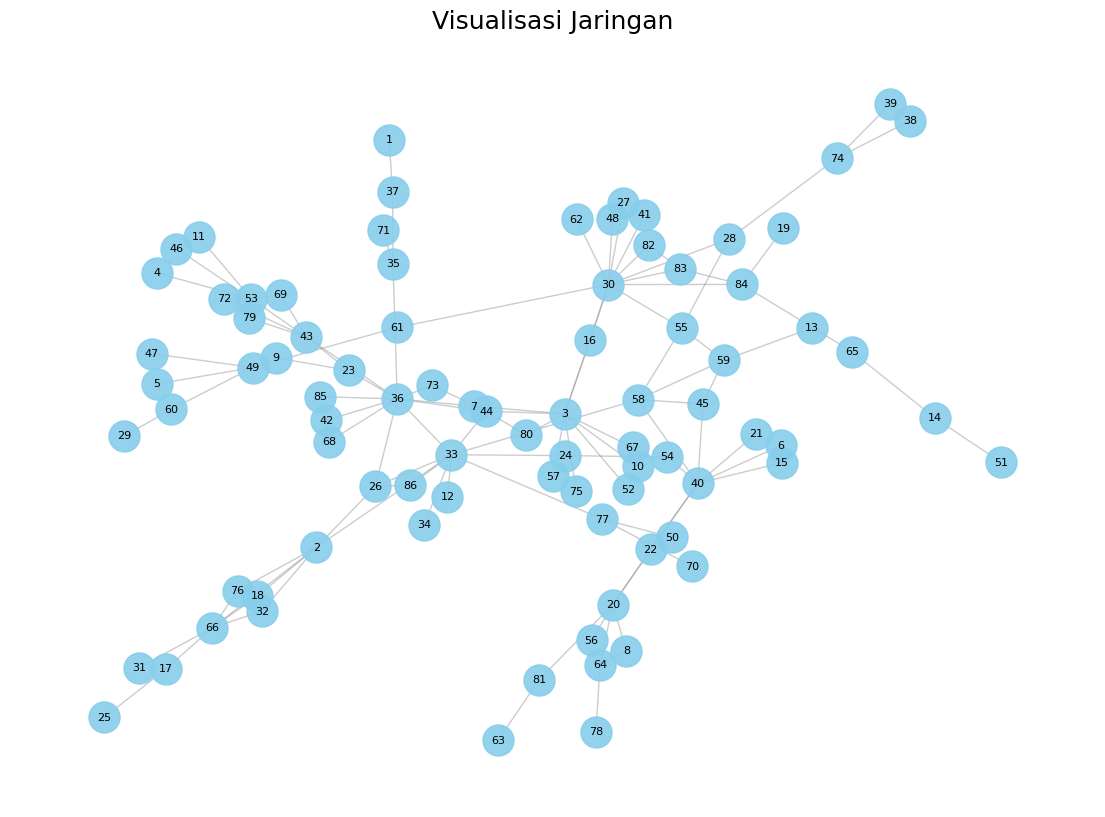

In [48]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color='skyblue',
    node_size=500,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color='gray',
    alpha=0.4
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title("Visualisasi Jaringan", fontsize=18)
plt.axis('off')
plt.show()

Jenis Graf: Undirected graph (dua arah), karena hubungan antar-node bersifat timbal balik.

Bobot Graf: Unweighted graph, karena semua koneksi memiliki bobot yang sama tanpa perbedaan tingkat kekuatan.

Alasan Pemilihan: Fokus analisis adalah melihat pola hubungan dan pengaruh umum. Struktur ini membuat jaringan lebih sederhana, mudah dianalisis, dan mudah divisualisasikan.

## Degree Centrality
Degree Centrality menunjukkan seberapa banyak koneksi langsung yang dimiliki oleh suatu node.

In [49]:

degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame({
    'Node': degree_centrality.keys(),
    'Degree Centrality': degree_centrality.values()
})

degree_df = degree_df.sort_values(
    by='Degree Centrality',
    ascending=False
)

display(
    degree_df.head(10)
    .style
    .hide(axis='index')
)


Node,Degree Centrality
30,0.141176
36,0.129412
3,0.117647
33,0.117647
40,0.094118
53,0.082353
43,0.070588
20,0.070588
2,0.070588
66,0.070588


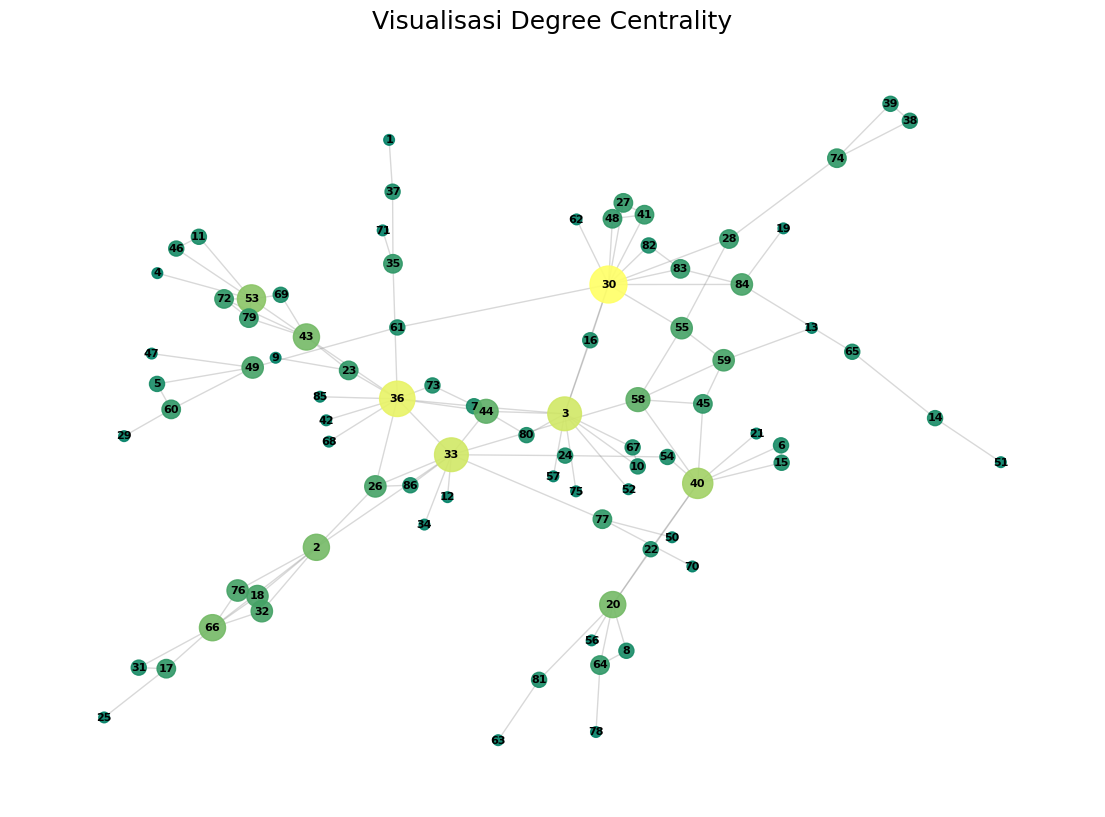

In [50]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

node_sizes = [v * 5000 for v in degree_centrality.values()]
node_colors = list(degree_centrality.values())

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.summer,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color='gray',
    alpha=0.3
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
    font_weight='bold'
)

plt.title("Visualisasi Degree Centrality", fontsize=18)
plt.axis('off')
plt.show()

Interpretasi Hasil :

- Node dengan degree centrality tertinggi (Node 30) menunjukkan bahwa node tersebut memiliki jumlah koneksi paling banyak.

- Node tersebut dapat dianggap sebagai pusat interaksi dalam jaringan.

- Semakin tinggi nilai degree centrality, semakin besar kemungkinan node tersebut berinteraksi dengan banyak node lain.

Kesimpulan:

Lima node dengan nilai degree centrality tertinggi merupakan node yang paling aktif dan memiliki pengaruh besar berdasarkan jumlah koneksi langsung.


## Betweenness Centrality
Betweenness Centrality menunjukkan seberapa sering suatu node menjadi penghubung jalur terpendek antar node lain.

In [51]:

betweenness_centrality = nx.betweenness_centrality(G)

between_df = pd.DataFrame({
    'Node': betweenness_centrality.keys(),
    'Betweenness Centrality': betweenness_centrality.values()
})

between_df = between_df.sort_values(
    by='Betweenness Centrality',
    ascending=False
)

display(
    between_df.head(10)
    .style
    .hide(axis='index')
)


Node,Betweenness Centrality
33,0.421849
30,0.400794
36,0.366807
58,0.352848
3,0.300373
40,0.243137
55,0.192717
44,0.185668
43,0.153221
2,0.152941


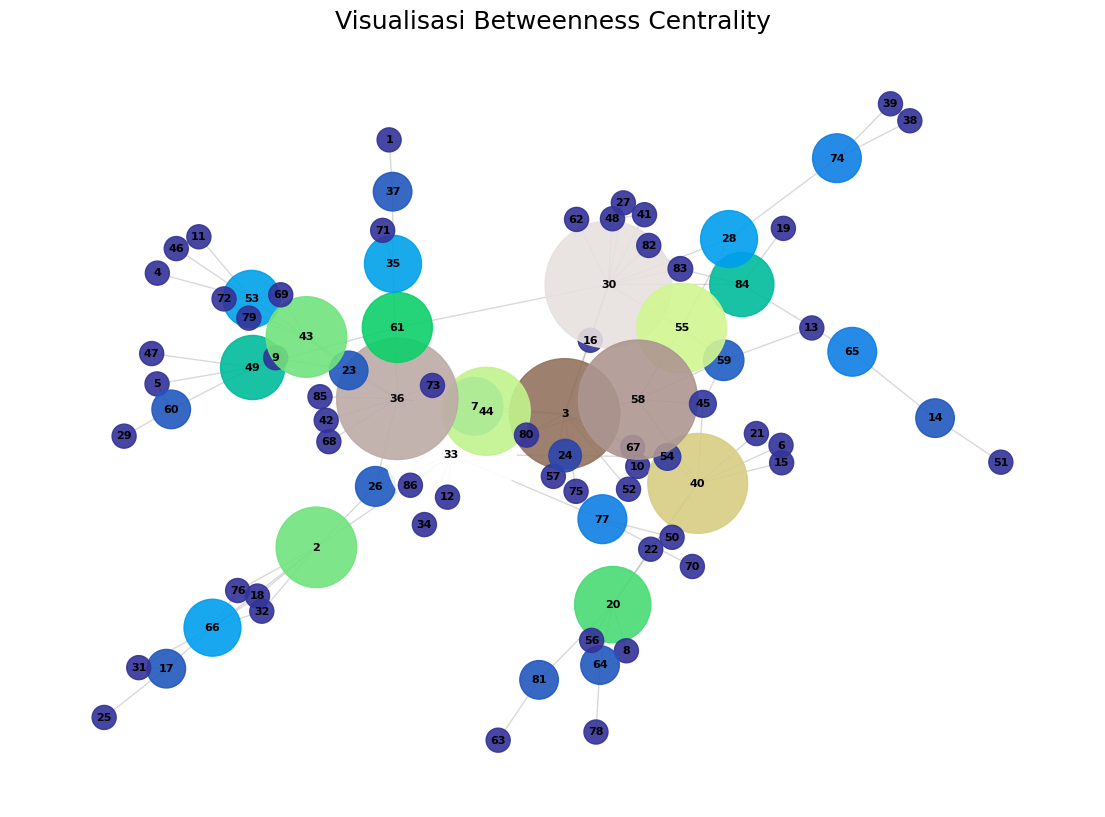

In [52]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

node_sizes = [v * 20000 + 300 for v in betweenness_centrality.values()]
node_colors = list(betweenness_centrality.values())

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.terrain,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color='gray',
    alpha=0.3
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
    font_weight='bold'
)

plt.title("Visualisasi Betweenness Centrality", fontsize=18)
plt.axis('off')
plt.show()

Interpretasi Hasil:
- Node 33 memiliki nilai betweenness centrality tertinggi dan memiliki peran penting dalam menjaga aliran hubungan dalam jaringan.

- Jika node tersebut dihilangkan, maka beberapa bagian jaringan dapat menjadi kurang terhubung.

- Node ini tidak selalu memiliki koneksi terbanyak, tetapi memiliki posisi strategis.


## Kesimpulan

Berdasarkan hasil analisis network graph pada dataset CA-Sandi Auths, dapat diketahui bahwa jaringan kolaborasi antar penulis memiliki struktur hubungan yang cukup kompleks dengan beberapa node yang memiliki pengaruh lebih besar dibanding node lainnya.

Hasil Degree Centrality menunjukkan bahwa terdapat beberapa author yang memiliki jumlah koneksi langsung paling banyak. Node-node tersebut dapat dianggap sebagai author yang aktif berkolaborasi dengan banyak author lain dalam jaringan.

Sementara itu, hasil Betweenness Centrality menunjukkan adanya beberapa node yang berperan penting sebagai penghubung antar kelompok author. Node dengan nilai betweenness tinggi memiliki posisi strategis karena membantu menjaga keterhubungan jaringan dan menjadi jalur penghubung antar bagian jaringan yang berbeda.

Hasil analisis juga menunjukkan bahwa node yang memiliki degree centrality tertinggi tidak selalu sama dengan node yang memiliki betweenness centrality tertinggi. Hal ini disebabkan karena degree centrality berfokus pada jumlah hubungan langsung, sedangkan betweenness centrality berfokus pada peran node sebagai penghubung dalam jaringan.

Visualisasi network graph membantu memperlihatkan pola hubungan antar author secara lebih jelas. Dengan menggunakan visualisasi berdasarkan centrality, node-node penting dalam jaringan dapat lebih mudah diidentifikasi baik dari sisi jumlah koneksi maupun perannya dalam menjaga struktur jaringan.